# 17 · GSE232381 · bulk_RNA_seq · heatmap, hierarchical clustering on both axes

Reads `expression.rds`, `metadata.rds`, and the GSE65391 end product `module_genes.csv`.

**Matrix.** The 16 samples × the 10 hub genes (highest kME in GSE65391) of each GSE65391 module,
where measured here, so the genes are the same as in notebook 07.

**Layout** (as in endotypes-proteomics): patients are rows, with their dendrogram and clinical
annotations on the left; genes are columns, with their dendrogram, names and WGCNA module colour on top.

 Each gene is
z-scored across the 16 samples; colours capped at ±2.5.

**Clustering.** `hclust`, `ward.D2`, Euclidean distance, on genes and on samples separately.

**Test.** The sample dendrogram is cut at k from 2 to 8 with the highest mean silhouette width. Groups
against `nephritis_active`: Fisher's exact test. **A finding** is p < 0.05.

In [1]:
source("../src/paths.R")
suppressMessages({library(ComplexHeatmap); library(circlize); library(cluster)})
x    <- readRDS(art("GSE232381", "expression.rds"))
meta <- readRDS(art("GSE232381", "metadata.rds"))
mg   <- read.csv(art("GSE65391", "module_genes.csv"))
hub  <- do.call(rbind, lapply(split(mg, mg$module), function(d) head(d[order(-d$kME), ], 10)))
hub  <- hub[hub$gene %in% rownames(x$E), ]
c(hub_genes_array = 10 * length(unique(mg$module)), measured_here = nrow(hub))
Z <- t(scale(t(x$E[hub$gene, meta$sample])))
Z <- Z[rowSums(is.na(Z)) == 0, ]; gene_module <- hub$module[match(rownames(Z), hub$gene)]
dim(Z)

hub_genes_array   measured_here 
            160             127

[1] 127  16

**Result.** 127 of the 160 GSE65391 hub genes pass this study's expression filter.

In [2]:
hc_genes   <- hclust(dist(Z), method = "ward.D2")
hc_samples <- hclust(dist(t(Z)), method = "ward.D2")
sil <- sapply(2:8, function(k) mean(silhouette(cutree(hc_samples, k), dist(t(Z)))[, "sil_width"]))
data.frame(k = 2:8, mean_silhouette = round(sil, 3))
K <- (2:8)[which.max(sil)]
group <- factor(paste0("H", cutree(hc_samples, K)))
table(group = group, nephritis = ifelse(meta$ln_active == 1, "active", "inactive"))
fisher.test(table(group, meta$ln_active))$p.value

k,mean_silhouette
<int>,<dbl>
2,0.311
3,0.149
4,0.148
5,0.140
6,0.138
7,0.127
8,0.119


     nephritis
group active inactive
   H1      9        5
   H2      1        1

[1] 1

**Result.** k = 2 (silhouette 0.311), but the split separates 2 samples (1 active, 1 inactive) from 14.
No association with nephritis activity (p = 1).

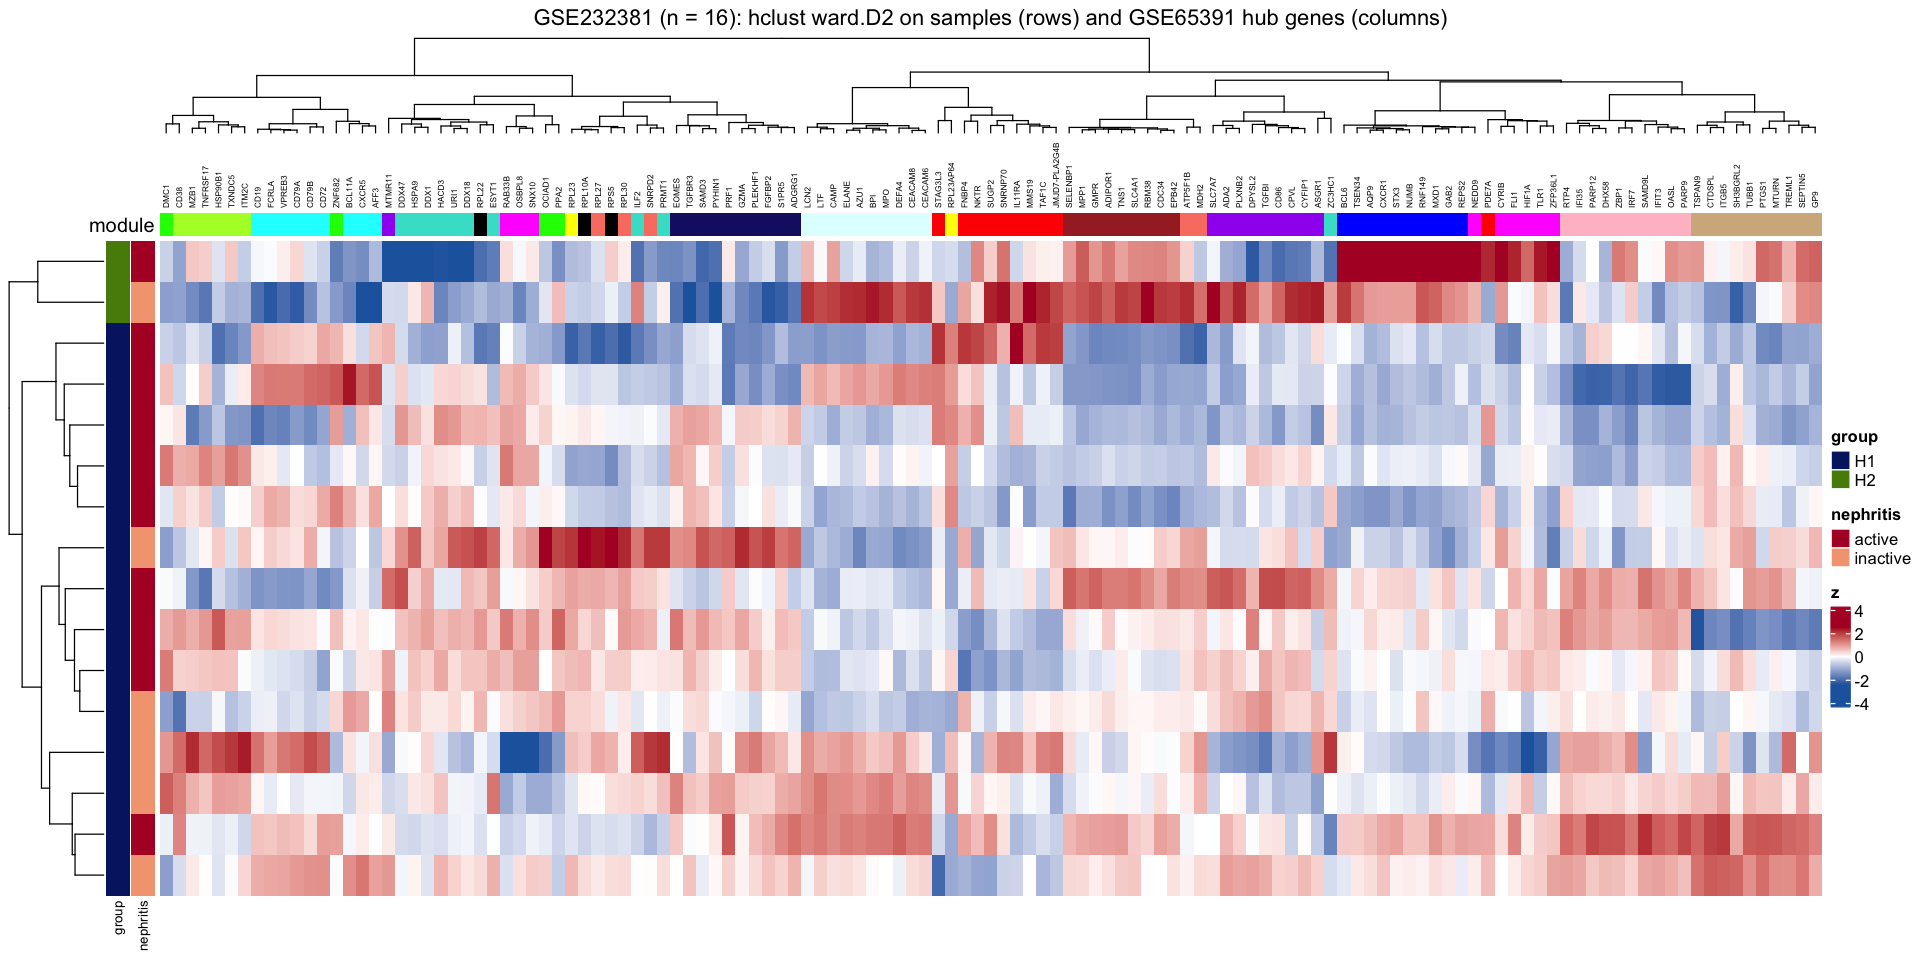

In [3]:
options(repr.plot.width = 16, repr.plot.height = 8)
Heatmap(t(pmin(pmax(Z, -2.5), 2.5)), name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
        cluster_rows = hc_samples, cluster_columns = hc_genes,
        row_dend_side = "left", column_dend_side = "top",
        row_dend_width = unit(20, "mm"), column_dend_height = unit(20, "mm"),
        show_row_names = FALSE, column_names_side = "top", column_names_gp = gpar(fontsize = 5),
        top_annotation = HeatmapAnnotation(module = gene_module, col = list(module = setNames(unique(gene_module), unique(gene_module))),
                                           show_legend = FALSE, annotation_name_side = "left"),
        left_annotation = rowAnnotation(group = group, nephritis = ifelse(meta$ln_active == 1, "active", "inactive"),
                                          col = list(nephritis = c(active = "#B2182B", inactive = "#F4A582")),
                                          annotation_name_gp = gpar(fontsize = 8)),
        column_title = "GSE232381 (n = 16): hclust ward.D2 on samples (rows) and GSE65391 hub genes (columns)")